# RetailPulse: AI-Powered Sales & Retail Analytics Platform
## Day 2 — Data Cleaning & Feature Engineering

**Module:** Feature Engineering (Phase 2)

Builds on `data/raw/sales_transactions.csv` from Day 1. This notebook:
1. Cleans the raw transactions per the quality issues flagged in Day 1
2. Derives `TotalPrice`
3. Builds RFM (Recency, Frequency, Monetary) features per customer
4. Builds lag features + rolling averages on the daily revenue series
5. Persists cleaned/feature tables for downstream notebooks (segmentation, forecasting, churn)

In [1]:
import os
import numpy as np
import pandas as pd

RAW_DIR = "../data/raw"
PROCESSED_DIR = "../data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

sales = pd.read_csv(f"{RAW_DIR}/sales_transactions.csv", parse_dates=["InvoiceDate"])
print(f"Raw rows: {len(sales):,}")
sales.head()

Raw rows: 471,418


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,522662,10103,SEASONAL ITEM 103,13,2023-01-02 08:00:00,10.78,100745.0,Australia
1,522662,10006,BAGS ITEM 6,6,2023-01-02 08:00:00,22.16,100745.0,Australia
2,522662,10119,SEASONAL ITEM 119,13,2023-01-02 08:00:00,9.80,100745.0,Australia
3,522663,10026,LIGHTING ITEM 26,10,2023-01-02 15:00:00,61.25,100745.0,Australia
4,656383,10074,TOYS ITEM 74,14,2023-01-02 16:00:00,70.91,104964.0,Ireland


## 1. Cleaning Rules

- Drop rows with missing `CustomerID` (can't attribute to a customer for segmentation/churn)
- Separate cancelled invoices (`InvoiceNo` starting with `C`) into their own returns table, rather than silently dropping them — useful later for net-revenue and return-rate analysis
- Drop invalid rows: `Quantity <= 0` or `UnitPrice <= 0` (after removing legitimate cancellations)
- Derive `TotalPrice = Quantity * UnitPrice`

In [2]:
raw_n = len(sales)

# Step 1: drop missing CustomerID
sales = sales.dropna(subset=["CustomerID"]).copy()
sales["CustomerID"] = sales["CustomerID"].astype(int)
after_dropna = len(sales)

# Step 2: split off cancellations into a returns table
is_cancelled = sales["InvoiceNo"].astype(str).str.startswith("C")
returns_df = sales[is_cancelled].copy()
sales = sales[~is_cancelled].copy()
after_cancel_split = len(sales)

# Step 3: drop invalid quantity/price rows
sales_clean = sales[(sales["Quantity"] > 0) & (sales["UnitPrice"] > 0)].copy()
after_invalid = len(sales_clean)

# Step 4: derive TotalPrice
sales_clean["TotalPrice"] = sales_clean["Quantity"] * sales_clean["UnitPrice"]
returns_df["TotalPrice"] = returns_df["Quantity"] * returns_df["UnitPrice"]

print(f"Raw rows:                {raw_n:,}")
print(f"After drop missing cust: {after_dropna:,} (-{raw_n - after_dropna:,})")
print(f"After split cancels:     {after_cancel_split:,} (-{after_dropna - after_cancel_split:,} moved to returns)")
print(f"After drop invalid:      {after_invalid:,} (-{after_cancel_split - after_invalid:,})")
print(f"\nFinal clean sales:  {len(sales_clean):,} rows")
print(f"Returns table:      {len(returns_df):,} rows")

Raw rows:                471,418
After drop missing cust: 433,728 (-37,690)
After split cancels:     425,020 (-8,708 moved to returns)
After drop invalid:      420,663 (-4,357)

Final clean sales:  420,663 rows
Returns table:      8,708 rows


In [3]:
sales_clean.to_csv(f"{PROCESSED_DIR}/sales_cleaned.csv", index=False)
returns_df.to_csv(f"{PROCESSED_DIR}/returns_cleaned.csv", index=False)
sales_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,522662,10103,SEASONAL ITEM 103,13,2023-01-02 08:00:00,10.78,100745,Australia,140.14
1,522662,10006,BAGS ITEM 6,6,2023-01-02 08:00:00,22.16,100745,Australia,132.96
2,522662,10119,SEASONAL ITEM 119,13,2023-01-02 08:00:00,9.80,100745,Australia,127.40
3,522663,10026,LIGHTING ITEM 26,10,2023-01-02 15:00:00,61.25,100745,Australia,612.50
4,656383,10074,TOYS ITEM 74,14,2023-01-02 16:00:00,70.91,104964,Ireland,992.74


## 2. RFM Feature Engineering

- **Recency** — days since each customer's last purchase (relative to a snapshot date one day after the latest invoice)
- **Frequency** — count of distinct invoices per customer
- **Monetary** — total revenue per customer

These three features feed the Day 3 segmentation (K-Means) notebook directly.

In [4]:
snapshot_date = sales_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = sales_clean.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
).reset_index()

# a couple of extra behavioral features that help both segmentation and churn later
rfm["AvgOrderValue"] = rfm["Monetary"] / rfm["Frequency"]
tenure = sales_clean.groupby("CustomerID")["InvoiceDate"].agg(lambda x: (x.max() - x.min()).days)
rfm["TenureDays"] = rfm["CustomerID"].map(tenure).clip(lower=1)
rfm["PurchaseFreqPerMonth"] = rfm["Frequency"] / (rfm["TenureDays"] / 30)

rfm.to_csv(f"{PROCESSED_DIR}/rfm_features.csv", index=False)
print(f"RFM table: {len(rfm):,} customers")
rfm.describe().round(2)

RFM table: 4,955 customers


,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,TenureDays,PurchaseFreqPerMonth
count,4955.00,4955.00,4955.00,4955.00,4955.00,4955.00,4955.00
mean,102497.12,115.96,30.51,28684.51,938.72,270.37,4.17
std,1442.64,145.14,28.66,27049.79,214.89,198.44,4.99
min,100000.00,1.00,1.00,16.60,16.60,1.00,0.37
25%,101248.50,6.00,9.00,8282.90,836.77,103.00,2.20
50%,102495.00,28.00,20.00,18964.77,934.32,225.00,3.27
75%,103746.50,207.00,43.00,41521.32,1032.99,414.50,4.60
max,104999.00,643.00,158.00,146109.32,2519.60,727.00,90.00


## 3. Time-Series Features — Lag & Rolling Averages

Resample cleaned sales into a daily revenue series, then engineer lag and rolling-window features. These feed the Day 5+ Prophet/LSTM forecasting notebooks (as exogenous regressors or as inputs to a supervised-learning-style forecaster).

In [5]:
daily = (sales_clean.groupby(sales_clean["InvoiceDate"].dt.date)
         .agg(Revenue=("TotalPrice", "sum"),
              Orders=("InvoiceNo", "nunique"),
              UnitsSold=("Quantity", "sum"))
         .reset_index()
         .rename(columns={"InvoiceDate": "Date"}))
daily["Date"] = pd.to_datetime(daily["Date"])
daily = daily.sort_values("Date").set_index("Date").asfreq("D")
daily[["Revenue", "Orders", "UnitsSold"]] = daily[["Revenue", "Orders", "UnitsSold"]].fillna(0)

# Lag features
for lag in [1, 7, 14, 30]:
    daily[f"Revenue_lag{lag}"] = daily["Revenue"].shift(lag)

# Rolling averages
for window in [7, 14, 30]:
    daily[f"Revenue_roll{window}_mean"] = daily["Revenue"].rolling(window).mean()
    daily[f"Revenue_roll{window}_std"] = daily["Revenue"].rolling(window).std()

# Calendar features
daily["DayOfWeek"] = daily.index.dayofweek
daily["IsWeekend"] = daily["DayOfWeek"].isin([5, 6]).astype(int)
daily["Month"] = daily.index.month

daily_reset = daily.reset_index()
daily_reset.to_csv(f"{PROCESSED_DIR}/timeseries_daily.csv", index=False)
print(f"Daily time-series: {len(daily_reset):,} days, {daily_reset.shape[1]} columns")
daily_reset.tail()

Daily time-series: 730 days, 17 columns


,Date,Revenue,Orders,UnitsSold,Revenue_lag1,Revenue_lag7,Revenue_lag14,Revenue_lag30,Revenue_roll7_mean,Revenue_roll7_std,Revenue_roll14_mean,Revenue_roll14_std,Revenue_roll30_mean,Revenue_roll30_std,DayOfWeek,IsWeekend,Month
725,2024-12-27,285811.81,313,6527,245806.99,315565.85,320374.64,295257.60,279389.200000,22225.545360,284894.217857,21421.312188,289662.091000,19924.887011,4,0,12
726,2024-12-28,294000.01,315,6425,285811.81,269145.71,300992.48,278173.43,282939.814286,22301.524044,284394.755714,21096.140622,290189.643667,19819.453526,5,1,12
727,2024-12-29,333438.46,361,7443,294000.01,279529.85,268829.13,307294.78,290641.044286,29176.104967,289009.707857,24258.924129,291061.099667,21128.998510,6,1,12
728,2024-12-30,263961.77,283,5827,333438.46,309763.21,306112.90,296588.42,284097.981429,29308.461122,285998.912857,24586.443727,289973.544667,21667.504578,0,0,12
729,2024-12-31,316274.24,334,7059,263961.77,302115.27,284212.21,300502.85,286120.691429,31187.510316,288289.057857,25867.098534,290499.257667,22118.420287,1,0,12


## 4. Sanity Check Plots

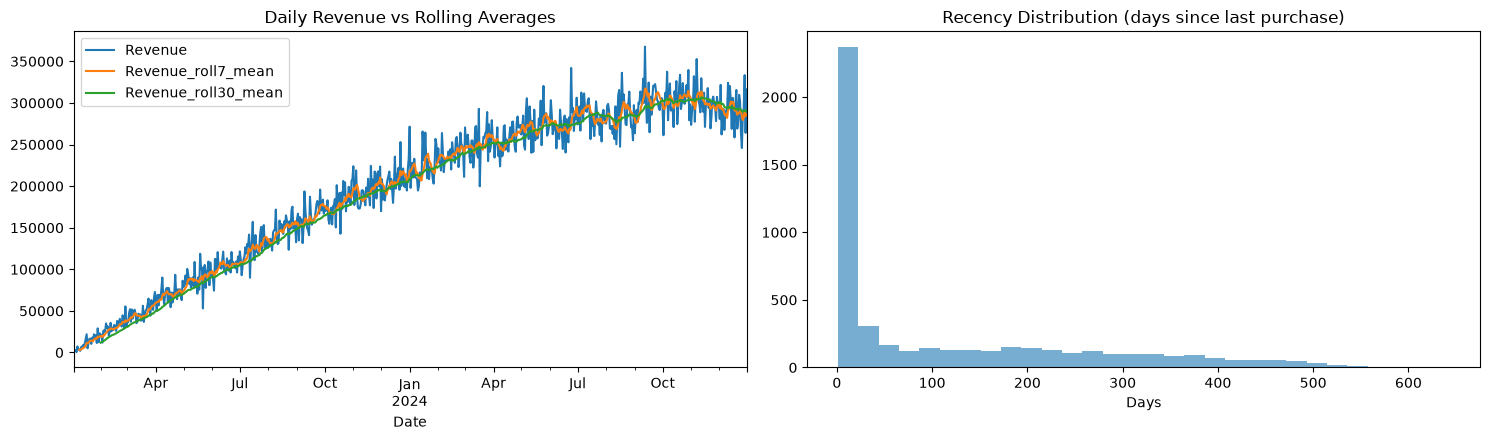

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

daily_reset.plot(x="Date", y=["Revenue", "Revenue_roll7_mean", "Revenue_roll30_mean"], ax=axes[0])
axes[0].set_title("Daily Revenue vs Rolling Averages")

axes[1].hist(rfm["Recency"], bins=30, alpha=0.6, label="Recency")
axes[1].set_title("Recency Distribution (days since last purchase)")
axes[1].set_xlabel("Days")

plt.tight_layout()
plt.savefig("../reports/day2_features_check.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Day 2 Checkpoint Summary

**Outputs saved:**
- `data/processed/sales_cleaned.csv` — cleaned transactions with `TotalPrice`
- `data/processed/returns_cleaned.csv` — cancelled-invoice rows, kept separately
- `data/processed/rfm_features.csv` — per-customer Recency/Frequency/Monetary + extras
- `data/processed/timeseries_daily.csv` — daily revenue with lag + rolling-window features
- `reports/day2_features_check.png`

**Next module:** `03_segmentation` — StandardScaler + K-Means clustering on the RFM table.